# Plot 1: Phase Plots

In [254]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["text.usetex"] = False
plt.rcParams["font.size"] = 12
plt.rcParams["font.family"] = 'lmodern'

def plot_band(ax, xarray, yarray, phase_lower, phase_higher,
              arrow=False, arrow_pos=0, hatch='', double=False):
    # Main curve
    ax.plot(xarray, yarray, color="black", linewidth=1, label=r'$\epsilon_k$')

    # Fills
    ax.fill_between(
        xarray, np.clip(yarray, phase_higher, 1), 1,
        facecolor="#ff2222", alpha=0.5,
        hatch=hatch, edgecolor="gray", linewidth=0.0,
        label="Empty"
    )
    ax.fill_between(
        xarray, np.clip(yarray, phase_lower, phase_higher), phase_higher,
        alpha=0.4, color="#23d544",
        where=(yarray <= phase_higher),
        label="Singly Occupied"
    )
    ax.fill_between(
        xarray, np.clip(yarray, -1, phase_lower), phase_lower,
        alpha=0.5, color="#1048ff",
        where=(yarray <= phase_lower),
        label="Doubly Occupied"
    )

    # Horizontal dashed lines
    if phase_higher != 1:
        ax.hlines(phase_higher, -np.arccos(-phase_higher), np.arccos(-phase_higher),
                colors="black", linestyles="dashed", linewidth=1)

    if phase_higher != 0:
        ax.hlines(phase_lower, -np.arccos(-phase_lower), np.arccos(-phase_lower),
                colors="black", linestyles="dashed", linewidth=1)

    # Optional arrow
    if arrow:
        ax.annotate(
            '', xy=(arrow_pos, phase_higher), xycoords='data',
            xytext=(arrow_pos, phase_lower), textcoords='data',
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1)
        )
        ax.text(arrow_pos + 0.1, (phase_lower + phase_higher)/2,
                r"$U$", va="center", ha="left")
        
        ax.annotate(
            '', xy=(np.pi - 0.15, 1.02), xycoords='data',
            xytext=(np.pi - 0.15, -1.02), textcoords='data',
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1)
        )
        ax.text(np.pi - 0.05, 0.3,
                r"$W$", va="center", ha="left")
        
    if double == True:
        ax.text(np.arccos(-phase_lower) + 0.1, phase_lower - 0.05,
                r'$\epsilon_{k_F}$', va="center", ha="left")
    else:
        if phase_lower != -1:    
            ax.text(np.arccos(-phase_lower) + 0.1, phase_lower,
                    r'$\epsilon_{D}$', va="center", ha="left")
        if phase_higher != 1:
            ax.text(np.arccos(-phase_higher) + 0.1, phase_higher,
                    r'$\epsilon_{S}$', va="center", ha="left")
        

    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_xticks([-np.pi, np.pi])
    ax.set_xticklabels([r"$-\pi$", r"$\pi$"])
    ax.set_yticks([])
    
    # ---- ADD AXIS ARROWHEADS ----
    # x-axis arrow (right end)
    ax.annotate(
        '',
        xy=(np.pi + 0.3, 0),
        xytext=(np.pi + 0.12, 0),
        arrowprops=dict(arrowstyle='->', color='black', linewidth=1),
        annotation_clip=False
    )

    # y-axis arrow (top end)
    ax.annotate(
        '',
        xy=(0, 1.25),
        xytext=(0, 1.07),
        arrowprops=dict(arrowstyle='->', color='black', linewidth=1),
        annotation_clip=False
    )
    
    
    # Axis labels
    ax.text(np.pi + 0.4, 0, r"$k$", va="center", ha="left")
    ax.text(0, 1.2, r"$\epsilon_k$", ha="center")



def plot_occupation_numbers(ax, k0, k1, klabels=False, double=False):
    k0 *= np.pi
    k1 *= np.pi
    x = np.linspace(-np.pi, np.pi, 5000)

    # Axes styling: x-axis through zero, no y-axis
    ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    ax.spines["bottom"].set_linewidth(1)

    ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Axis labels
    ax.text(0, 2.3, r"$n_k$", ha="center")
    ax.text(np.pi + 0.1, 0, r"$k$", va="center")

    f = np.piecewise(
        x,
        [np.abs(x) < k0, (np.abs(x) >= k0) & (np.abs(x) < k1), np.abs(x) >= k1],
        [2, 1, 0]
    )

    line, = ax.plot(x, f, color="black", linewidth=1, label=r'$n_k$', zorder=2)

    # Fills
    mask = (x >= -k0) & (x <= k0)
    ax.fill_between(x[mask], 0, 2,
                    alpha=0.5, color="#1048ff", label="Doubly Occupied")
    ax.fill_between(x, 0, 1,
                    alpha=0.4, color="#23d544", where=(f == 1),
                    label="Singly Occupied")
    ax.fill_between(x, 0.1, 0,
                    alpha=0.5, color="#ff2222", where=(f == 0),
                    label="Empty")

    if klabels == True:
    # Axis ticks/labels:

        ax.set_xticks([-np.pi, -k1, -k0, 0, k0, k1, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$-k_S$", r"$-k_D$", 0,
                            r"$k_D$", r"$k_S$", r"$\pi$"])
        ax.set_yticks([1])
        ax.text(-0.2, 2.1, "2", ha="right", va="center",
                zorder=10, clip_on=False, transform=ax.transData)
        
        ax.vlines((-k0, k0), 0, 1, 'black', linestyles='dashed', linewidth=1)        
    else:
        """
        ax.set_xticks([-np.pi, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$\pi$"])
        """
        if k1 == np.pi:
            if k0 != 0:
                ax.set_yticks([1])
                ax.text(-0.2, 2.1, "2", ha="right", va="center",
                    zorder=10, clip_on=False, transform=ax.transData)
                ax.vlines((-k0, k0), 0, 1, 'black', linestyles='dashed', linewidth=1)
                ax.set_xticks([-np.pi,-k0, 0, k0, np.pi])
                ax.set_xticklabels([r"$-\pi$", r"$-k_D$", 0, r"$k_D$", r"$\pi$"])
            else:
                ax.set_yticks([2])
                ax.text(-0.2, 1.1, "1", ha="right", va="center",
                        zorder=10, clip_on=False, transform=ax.transData)
                ax.set_xticks([-np.pi, 0, np.pi])
                ax.set_xticklabels([r"$-\pi$", 0, r"$\pi$"])
        else:
            if k0 == 0:
                ax.set_xticks([-np.pi,-k1, 0, k1, np.pi])
                ax.set_xticklabels([r"$-\pi$", r"$-k_S$", 0, r"$k_S$", r"$\pi$"])
                ax.set_yticks([2])
                ax.text(-0.2, 1.1, "1", ha="right", va="center",
                    zorder=10, clip_on=False, transform=ax.transData)
            else:
                ax.set_yticks([1])
                ax.text(-0.2, 2.1, "2", ha="right", va="center",
                    zorder=10, clip_on=False, transform=ax.transData)
                if k1 != k0:
                    ax.vlines((-k0, k0), 0, 1, 'black', linestyles='dashed', linewidth=1)
                    ax.set_xticks([-np.pi,-k0, 0, k0, np.pi])
                    ax.set_xticklabels([r"$-\pi$", r"$-k_D$", 0, r"$k_D$", r"$\pi$"])

    if double == True:
        ax.set_yticks([1])
        ax.text(-0.2, 2.1, "2", ha="right", va="center",
                zorder=10, clip_on=False, transform=ax.transData)
        ax.set_xticks([-np.pi,-k1, 0, k1, np.pi])
        ax.set_xticklabels([r"$-\pi$", r"$-k_F$", 0, r"$k_F$", r"$\pi$"])


    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(0, 2.2)



k = np.linspace(-np.pi, np.pi, 1000)
eps_k = -np.cos(k)



<>:167: SyntaxWarning: invalid escape sequence '\p'
<>:167: SyntaxWarning: invalid escape sequence '\p'
/var/folders/6g/kfvfxvvs2473z8z47g0kr34w0000gn/T/ipykernel_3967/55262380.py:167: SyntaxWarning: invalid escape sequence '\p'
  """


findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.


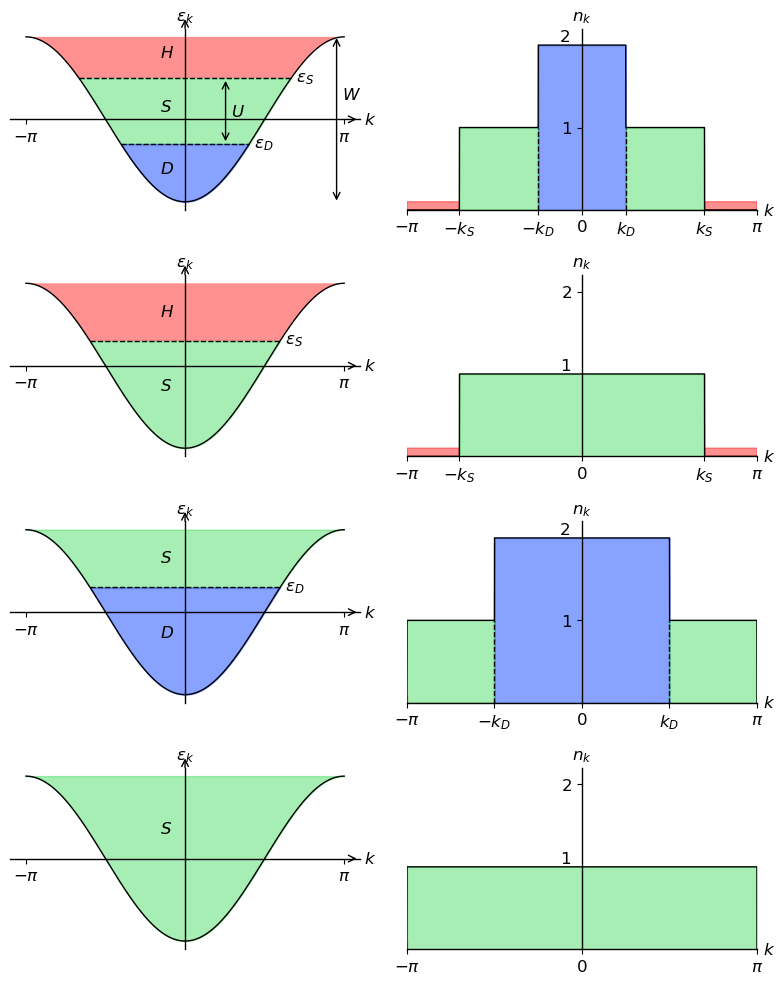

In [255]:
# 1. Create the grid (4 rows, 2 columns)
# figsize=(width, height) - adjust this to make it look less cramped
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 10))

# 2. Flatten the axes array for easy iteration
# 'axes' is a 2D array (4x2), flattening it makes it 1D (length 8)
axes_flat = axes.flatten()

# 3. Loop through and plot your data
plot_band(axes_flat[0], k, eps_k, -0.3, 0.5, arrow=True, arrow_pos=0.8)
plot_band(axes_flat[2], k, eps_k, -1, 0.3, arrow=False, arrow_pos=0.8)
plot_band(axes_flat[4], k, eps_k, 0.3, 1, arrow=False, arrow_pos=0.8)
plot_band(axes_flat[6], k, eps_k, -1, 1, arrow=False, arrow_pos=0.8)

plot_occupation_numbers(axes_flat[1], 0.25, 0.7, klabels=True)
plot_occupation_numbers(axes_flat[3], 0, 0.7)
plot_occupation_numbers(axes_flat[5], 0.5, 1)
plot_occupation_numbers(axes_flat[7], 0, 1)

axes_flat[0].text(-0.5, 0.75, r"$H$")
axes_flat[0].text(-0.5, 0.1, r"$S$")
axes_flat[0].text(-0.5, -0.65, r"$D$")

axes_flat[2].text(-0.5, 0.6, r"$H$")
axes_flat[2].text(-0.5, -0.3, r"$S$")

axes_flat[4].text(-0.5, 0.6, r"$S$")
axes_flat[4].text(-0.5, -0.3, r"$D$")

axes_flat[6].text(-0.5, 0.3, r"$S$")




# 4. Critical step: Use tight_layout to prevent overlapping labels
plt.tight_layout()
plt.show()

## Alternative: Box Plot

findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: F

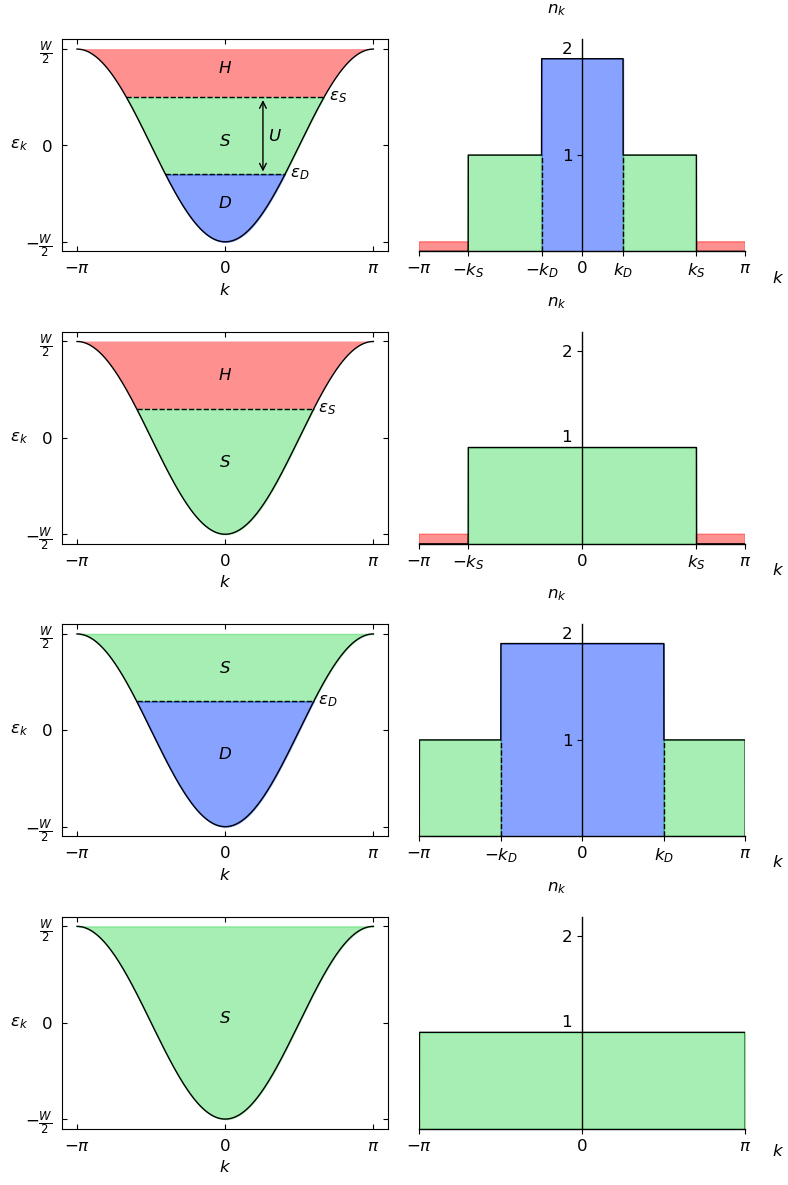

In [134]:

def plot_band_box(ax, xarray, yarray, phase_lower, phase_higher,
              arrow=False, arrow_pos=0, hatch='', double=False, labels=True):
    # Main curve
    ax.plot(xarray, yarray, color="black", linewidth=1, label=r'$\epsilon_k$')

    # Fills
    ax.fill_between(
        xarray, np.clip(yarray, phase_higher, 1), 1,
        facecolor="#ff2222", alpha=0.5,
        hatch=hatch, edgecolor="gray", linewidth=0.0,
        label="Empty"
    )
    ax.fill_between(
        xarray, np.clip(yarray, phase_lower, phase_higher), phase_higher,
        alpha=0.4, color="#23d544",
        where=(yarray <= phase_higher),
        label="Singly Occupied"
    )
    ax.fill_between(
        xarray, np.clip(yarray, -1, phase_lower), phase_lower,
        alpha=0.5, color="#1048ff",
        where=(yarray <= phase_lower),
        label="Doubly Occupied"
    )

    # Horizontal dashed lines
    if phase_higher != 1:
        ax.hlines(phase_higher, -np.arccos(-phase_higher), np.arccos(-phase_higher),
                colors="black", linestyles="dashed", linewidth=1)

    if phase_higher != 0:
        ax.hlines(phase_lower, -np.arccos(-phase_lower), np.arccos(-phase_lower),
                colors="black", linestyles="dashed", linewidth=1)

    # Optional arrow
    if arrow:
        ax.annotate(
            '', xy=(arrow_pos, phase_higher), xycoords='data',
            xytext=(arrow_pos, phase_lower), textcoords='data',
            arrowprops=dict(arrowstyle='<->', color='black', linewidth=1)
        )
        ax.text(arrow_pos + 0.1, (phase_lower + phase_higher)/2,
                r"$U$", va="center", ha="left")
        

    if labels:    
        if double == True:
            ax.text(np.arccos(-phase_lower) + 0.1, phase_lower - 0.05,
                    r'$\epsilon_{k_F}$', va="center", ha="left")
        else:
            if phase_lower != -1:    
                ax.text(np.arccos(-phase_lower) + 0.1, phase_lower,
                        r'$\epsilon_{D}$', va="center", ha="left")
            if phase_higher != 1:
                ax.text(np.arccos(-phase_higher) + 0.1, phase_higher,
                        r'$\epsilon_{S}$', va="center", ha="left")
            

    # Clean up axes
    # Axes styling: x-axis through zero, no y-axis
    #ax.spines["bottom"].set_position("zero")
    ax.spines["bottom"].set_color("black")
    #ax.spines["bottom"].set_linewidth(1)

    #ax.spines["left"].set_position("zero")
    ax.spines["left"].set_color("black")
    #ax.spines["left"].set_linewidth(1)

    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)

    ax.tick_params(top=True, right=True, direction='in', pad=7)

    if labels:
        ax.set_xticks([-np.pi, 0, np.pi])
        ax.set_xticklabels([r"$-\pi$", 0, r"$\pi$"])
        ax.set_yticks([-1, 0, 1])
        ax.set_yticklabels([r"$-\frac{W}{2}$", 0, r"$\frac{W}{2}$"])

        ax.set_xlabel(r"$k$")
        ax.set_ylabel(r"$\epsilon_k$", rotation='horizontal', ha="center", va="center")

    


# 1. Create the grid (4 rows, 2 columns)
# figsize=(width, height) - adjust this to make it look less cramped
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(8, 12))

# 2. Flatten the axes array for easy iteration
# 'axes' is a 2D array (4x2), flattening it makes it 1D (length 8)
axes_flat = axes.flatten()

# 3. Loop through and plot your data
plot_band_box(axes_flat[0], k, eps_k, -0.3, 0.5, arrow=True, arrow_pos=0.8)
plot_band_box(axes_flat[2], k, eps_k, -1, 0.3, arrow=False, arrow_pos=0.8)
plot_band_box(axes_flat[4], k, eps_k, 0.3, 1, arrow=False, arrow_pos=0.8)
plot_band_box(axes_flat[6], k, eps_k, -1, 1, arrow=False, arrow_pos=0.8)

plot_occupation_numbers(axes_flat[1], 0.25, 0.7, klabels=True)
plot_occupation_numbers(axes_flat[3], 0, 0.7)
plot_occupation_numbers(axes_flat[5], 0.5, 1)
plot_occupation_numbers(axes_flat[7], 0, 1)

axes_flat[0].text(0, 0.75, r"$H$", ha="center")
axes_flat[0].text(0, 0, r"$S$", ha="center")
axes_flat[0].text(0, -0.65, r"$D$", ha="center")

axes_flat[2].text(0, 0.6, r"$H$", ha="center")
axes_flat[2].text(0, -0.3, r"$S$", ha="center")

axes_flat[4].text(0, 0.6, r"$S$", ha="center")
axes_flat[4].text(0, -0.3, r"$D$", ha="center")

axes_flat[6].text(0, 0, r"$S$", ha="center")

plt.tight_layout()
plt.show()


# Dimensionless Phase Diagram

findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: F

Canvas size (set)     : 4.252 in x 3.280 in = 10.80 cm x 8.33 cm
Tight bbox (rendered)  : 3.86847 in x 3.05845 in = 9.82591 cm x 7.76846 cm


findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.


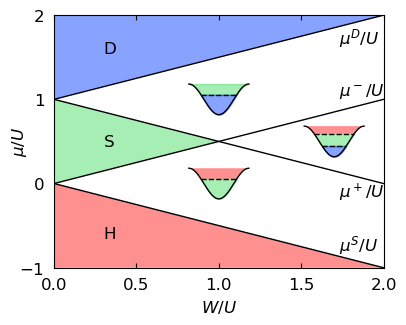

In [161]:
from matplotlib.ticker import MultipleLocator

def plot_2nd_pd(y_max, save_title=''):
    # Create the plot
    fig, ax = plt.subplots()

    fig.set_size_inches(6.377953 / 1.5, 2.73341 * 1.2)

    x1 = np.linspace(0, 2, 500)

    muplus = 1 - x1 / 2
    muminus = x1 / 2

    muE =  - x1 / 2
    muF = 1 + x1 / 2

    ax.plot(x1, muplus, color='black', linewidth=1)
    ax.plot(x1, muminus, color='black', linewidth=1)
    ax.plot(x1, muE, color='black', linewidth=1)
    ax.plot(x1, muF, color='black', linewidth=1)

    #ax.text(1.7, 0.5, 'I', ha='center', va='center')
    #ax.text(1, 0, 'II', ha='center', va='center')
    #ax.text(1, 1, 'III', ha='center', va='center')
    ax.text(0.3, 0.5, 'S', ha='left', va='center')

    ax.text(0.3, 1.6, 'D', ha='left', va='center')
    ax.text(0.3, -0.6, 'H', ha='left', va='center')

    ax.text(1.73, 1.73, r'$\mu^D/U$', ha='left', va='center')
    ax.text(1.73, 1.10, r'$\mu^-/U$', ha='left', va='center')
    ax.text(1.73, -0.10, r'$\mu^+/U$', ha='left', va='center')
    ax.text(1.73, -0.73, r'$\mu^S/U$', ha='left', va='center')
    """
    ax.annotate(
    '', 
    xy=(0.3, 1.15),    # arrowhead (end point)
    xytext=(0.3, 1.5),# tail (start point)
    arrowprops=dict(
        arrowstyle='->',   # simple one-sided arrow
        color='black',
        linewidth=1
    )
    )
    #### muminus ####
    ax.annotate(
    '', 
    xy=(1.7, 0.85),    # arrowhead (end point)
    xytext=(1.7, 1.2),# tail (start point)
    arrowprops=dict(
        arrowstyle='->',   # simple one-sided arrow
        color='black',
        linewidth=1
    )
    )
    #### muplus ####
    ax.annotate(
    '', 
    xy=(1.7, 0.15),    # arrowhead (end point)
    xytext=(1.7, -0.2),# tail (start point)
    arrowprops=dict(
        arrowstyle='->',   # simple one-sided arrow
        color='black',
        linewidth=1
    )
    )
    #### muE ####
    ax.annotate(
    '', 
    xy=(0.3, -0.15),    # arrowhead (end point)
    xytext=(0.3, -0.5),# tail (start point)
    arrowprops=dict(
        arrowstyle='->',   # simple one-sided arrow
        color='black',
        linewidth=1
    )
    )
    """
    """
    ax.fill_between(x1, muF, muplus, alpha=0.5, color="#bdffe6", label='Metallic')
    ax.fill_between(x1, muE, muminus, where=(muplus > muminus), alpha=0.5, color="#bdffe6")
    ax.fill_between(x1, muE, muplus, where=(muplus < muminus), alpha=0.5, color="#bdffe6")
    ax.fill_between(x1, muminus, muplus, where=(muplus > muminus), alpha=0.4, color="#fff0ab", label='Insulating')
    """
    ax.fill_between(x1, muminus, muplus, where=(muplus > muminus), facecolor="#23d544", alpha=0.4, label='Insulating')
    ax.fill_between(x1, muF, 2, facecolor="#1048ff", alpha=0.5)
    ax.fill_between(x1, -1, muE, facecolor="#ff2222", alpha=0.5)



    # Labels and legend
    ax.set_xlabel(r'$W/U$')
    ax.set_ylabel(r'$\mu / U$', va='top', labelpad=7)
    
    ax.set_xlim(0, 2)
    ax.set_ylim(1-y_max, y_max)
    ax.tick_params(top=True, right=False, left=False, direction='in', pad=7)
    #ax.tick_params(top=False, right=False)
    # Set major tick intervals
    ax.xaxis.set_major_locator(MultipleLocator(0.5))  # x-axis ticks every 0.2 units
    ax.yaxis.set_major_locator(MultipleLocator(1))  # y-axis ticks every 0.5 units

    # --- Inset 1: Region SD  ---
    # [x_pos, y_pos, width_size, height_size]
    ax_ins1 = ax.inset_axes([0.8, 0.8, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins1, k, eps_k, 0.3, 1, labels=False)


    # --- Inset 2: Region HS  ---
    ax_ins2 = ax.inset_axes([0.8, -0.2, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins2, k, eps_k, -1, 0.3, labels=False)

    # --- Inset 2: Region HS  ---
    ax_ins3 = ax.inset_axes([1.5, 0.3, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins3, k, eps_k, -0.3, 0.5, labels=False)

    # Clean up insets (optional)
    for a in [ax_ins1, ax_ins2, ax_ins3]:
        a.set_xticks([]); a.set_yticks([])
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
        a.spines["left"].set_visible(False)
        a.spines["bottom"].set_visible(False)

    if save_title != '':
        plt.savefig(save_title, dpi=1000, bbox_inches="tight")

    # --- after you finish building the figure (plot, legend, etc.) ---
    fig.canvas.draw()          # ensure renderer exists and artists have positions
    renderer = fig.canvas.get_renderer()

    # 1) Canvas nominal size (the size you set via set_size_inches)
    canvas_w_in, canvas_h_in = fig.get_size_inches()
    print(f"Canvas size (set)     : {canvas_w_in:.3f} in x {canvas_h_in:.3f} in "
        f"= {canvas_w_in*2.54:.2f} cm x {canvas_h_in*2.54:.2f} cm")

    # 2) Tight bounding box: the actual drawn extents that 'bbox_inches=tight' would use
    tight_bbox = fig.get_tightbbox(renderer)   # Bbox in display units (pixels or points)
    # convert display units -> inches by dividing by figure dpi
    tight_w_in = tight_bbox.width 
    tight_h_in = tight_bbox.height
    print(f"Tight bbox (rendered)  : {tight_w_in:.5f} in x {tight_h_in:.5f} in "
        f"= {tight_w_in*2.54:.5f} cm x {tight_h_in*2.54:.5f} cm")

    plt.show()

plot_2nd_pd(2)

# 1D Phase Diagram

findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: Font family 'lmodern' not found.
findfont: F

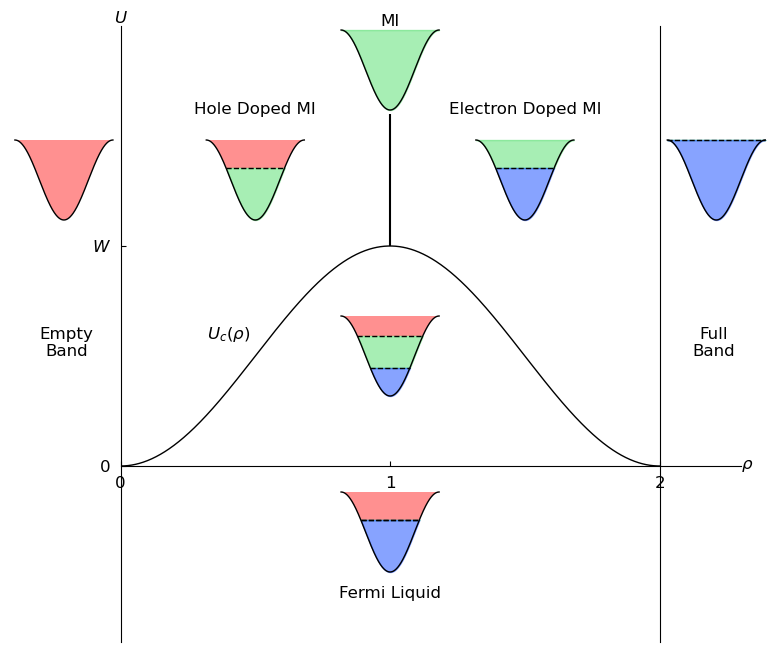

In [223]:
def plot_pd(rho: np.array, U_c_norm: np.array, save_title=''):
    # Create the plot
    fig, ax = plt.subplots(figsize=(8,8))

    # fig.set_size_inches(6.377953 / 1.5, 2.73341 * 1.2)

    ax.plot(rho, U_c_norm, label=r'$U_c (\rho)$', color='black', linewidth=1)

    ax.spines["top"].set_visible(False)

    ax.vlines(x=1, ymin=1, ymax=1.6, color='black', linestyle='-')

    # Labels and legend
    ax.text(0, 2, r"$U$", ha="center", va="bottom")
    ax.text(2.3, 0, r"$\rho$", va="center", ha="left")

    ax.set_xlim(0, 2.3)
    ax.set_ylim(-0.8, 2)
    ax.tick_params(top=False, right=False, direction='in', pad=7)
    # Set major tick intervals
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 1])
    ax.set_yticklabels([0, r"$W$"])

    ax.spines["bottom"].set_position("zero")
    ax.spines["right"].set_position(("data", 2))

    ax.text(0.4, 0.6, r"$U_c(\rho)$", va="center", ha="center")

    # --- Inset 1: Region SD  ---
    # [x_pos, y_pos, width_size, height_size]
    ax_ins1 = ax.inset_axes([1.3, 1.1, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins1, k, eps_k, 0.3, 1, labels=False)

    # --- Inset 2: Region HS  ---
    ax_ins2 = ax.inset_axes([0.3, 1.1, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins2, k, eps_k, -1, 0.3, labels=False)

    # --- Inset 2: Region HS  ---
    ax_ins3 = ax.inset_axes([0.8, 0.3, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins3, k, eps_k, -0.3, 0.5, labels=False)

    ax_ins4 = ax.inset_axes([0.8, -0.5, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins4, k, eps_k, 0.3, 0.3, labels=False)

    ax_ins5 = ax.inset_axes([0.8, 1.6, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins5, k, eps_k, -1, 1, labels=False)

    ax_ins6 = ax.inset_axes([2.01, 1.1, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins6, k, eps_k, 1, 1, labels=False)

    ax_ins7 = ax.inset_axes([-0.41, 1.1, 0.4, 0.4], transform=ax.transData)
    plot_band_box(ax_ins7, k, eps_k, -1, -1, labels=False)

    # Clean up insets (optional)
    for a in [ax_ins1, ax_ins2, ax_ins3, ax_ins4, ax_ins5, ax_ins6, ax_ins7]:
        a.set_xticks([]); a.set_yticks([])
        a.spines["top"].set_visible(False)
        a.spines["right"].set_visible(False)
        a.spines["left"].set_visible(False)
        a.spines["bottom"].set_visible(False)


    ax.text(1, -0.6, "Fermi Liquid", ha="center")
    ax.text(0.5, 1.6, "Hole Doped MI", ha="center")
    ax.text(1.5, 1.6, "Electron Doped MI", ha="center")
    ax.text(-0.2, 0.5, "Empty\nBand", ha="center")
    ax.text(2.2, 0.5, "Full\nBand", ha="center")
    ax.text(1, 2.0, "MI", ha="center")

    if save_title != '':
        plt.savefig(save_title, dpi=1000, bbox_inches="tight")

    plt.show()

rho = np.linspace(0, 2, 1000)
U_c = np.square(np.sin(rho * np.pi /2))

plot_pd(rho, U_c)


